In [ ]:
import pandas as pd
import umap.umap_ as umap
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

RANDOM_STATE = 61026

### General data exploration

In [148]:
all_sources = pd.read_csv("all_sources_isc_vgg_embeddings.csv")

In [149]:
all_sources

,source,label,Value,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,...,vgg_502,vgg_503,vgg_504,vgg_505,vgg_506,vgg_507,vgg_508,vgg_509,vgg_510,vgg_511
0,mtt,C,94.774444,0.011359,0.241203,0.344854,0.000000,11.211005,0.004637,0.0,...,0.188881,0.0,0.954637,2.482550,0.000000,0.118003,0.000000,0.000000,1.703285,0.000000
1,mtt,C,94.774444,0.025853,0.000000,1.069848,0.000000,11.320415,0.000000,0.0,...,0.000000,0.0,0.168406,6.162180,0.000000,0.107752,0.000000,0.271620,4.474264,0.000000
2,mtt,C,94.774444,0.480963,0.000000,3.107252,0.000000,4.831994,0.064862,0.0,...,0.124030,0.0,0.665731,1.306546,0.030879,0.144269,0.005907,0.232978,1.154307,0.000000
3,mtt,C,94.774444,0.000000,0.000000,0.058814,0.000000,6.624664,0.000000,0.0,...,0.316281,0.0,0.318968,0.330109,0.480029,0.542135,0.000000,0.008872,3.581180,0.289227
4,mtt,C,94.774444,0.000000,0.000000,0.119758,0.000000,8.961069,0.000000,0.0,...,0.099849,0.0,0.034700,1.626213,0.012560,0.605835,0.000000,0.025230,1.533522,0.180085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23840,study18,S,NaN,0.059749,0.000000,0.000000,0.312913,0.053099,0.000000,0.0,...,0.198128,0.0,0.024524,0.771849,0.000000,0.002295,0.000000,0.000000,0.800087,0.000000
23841,study18,S,NaN,0.000000,0.000000,1.000184,0.000000,0.740112,0.000000,0.0,...,0.434452,0.0,0.000000,0.732429,0.000000,0.662563,0.000000,0.000000,0.678243,0.000000
23842,study18,S,NaN,0.000000,0.000000,0.677755,0.000000,2.872867,0.000000,0.0,...,2.191196,0.0,0.023503,0.882949,0.000000,0.059748,0.000000,0.000000,0.889415,0.000000
23843,study18,S,NaN,0.000000,0.000000,0.020610,0.000000,2.368106,0.035866,0.0,...,0.834328,0.0,0.051658,0.039791,4.803977,0.000000,0.000000,0.000000,1.185690,0.000000


In [ ]:
print(all_sources["source"].unique())
print(all_sources["label"].unique())

<StringArray>
['mtt', 'alamar', 'jimt', 'chroma', 'study18']
Length: 5, dtype: str
<StringArray>
['C', 'S', 'I']
Length: 3, dtype: str


In [151]:
all_sources.describe()

,Value,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,vgg_7,vgg_8,...,vgg_502,vgg_503,vgg_504,vgg_505,vgg_506,vgg_507,vgg_508,vgg_509,vgg_510,vgg_511
count,982.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,...,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000,23845.000000
mean,88.145686,1.498470,0.304781,1.085484,0.355538,0.439499,0.131011,0.114659,0.667286,0.026225,...,1.339190,0.166183,1.608867,0.542775,2.118624,0.280964,0.391336,0.088719,1.003547,0.173210
std,61.962304,2.484030,0.705270,1.437526,0.591818,0.949694,0.288222,0.292859,1.165890,0.125531,...,1.733397,0.278504,2.038703,0.907855,1.650250,0.588996,0.685252,0.279512,0.648554,0.408416
min,2.454000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.575000,0.000000,0.000000,0.072552,0.000000,0.000000,0.000000,0.000000,0.005921,0.000000,...,0.307238,0.000000,0.171718,0.029046,0.930009,0.000000,0.000000,0.000000,0.557403,0.000000
50%,94.945000,0.377835,0.000000,0.539538,0.098405,0.091179,0.000811,0.000000,0.172500,0.000000,...,0.838379,0.040099,0.808060,0.189393,1.762812,0.066034,0.064119,0.000000,0.863602,0.015121
75%,120.987500,1.899906,0.273758,1.556678,0.449837,0.510618,0.131086,0.089827,0.762958,0.000000,...,1.746428,0.220630,2.259020,0.676995,2.912449,0.317651,0.496297,0.017148,1.279614,0.148648
max,271.664444,26.383339,11.761838,15.077735,8.261716,16.409120,5.181079,5.634606,12.246122,4.030687,...,18.085924,4.166559,16.153600,16.235281,18.388905,8.562617,8.496418,5.308903,8.755614,8.346353


In [ ]:
vgg_columns = [column for column in all_sources.columns if column.startswith("vgg_")]
metadata_columns = [
    column for column in all_sources.columns if column not in vgg_columns
]
print(metadata_columns)

['source', 'label', 'Value']


In [153]:
na_counts = all_sources.isnull().sum()
print(na_counts[na_counts > 0])

Value    22863
dtype: int64


The `Value` column is the only one containing NAs, we can check additionally if this coincides with some source or label columns.

In [ ]:
df_filtered_no_na = all_sources.dropna(subset=["Value"])

print(f"Sources without NA values{df_filtered_no_na['source'].unique().tolist()}")
print(f"Labels without NA values {df_filtered_no_na['label'].unique().tolist()}")
df_filtered = all_sources[all_sources["Value"].isna()]
print()
print(f"Sources with NA values{df_filtered['source'].unique().tolist()}")
print(f"Labels with NA values {df_filtered['label'].unique().tolist()}")

Sources without NA values['mtt', 'alamar']
Labels without NA values ['C', 'S', 'I']

Sources with NA values['jimt', 'chroma', 'study18']
Labels with NA values ['I', 'C', 'S']


We can see that NA in value is definitelly source-dependent. NAs are present for `jimt`, `chroma`, `study18` sources and only for them.

Inspecting value column in more details (where present)

Number of unique Value measurements: 652


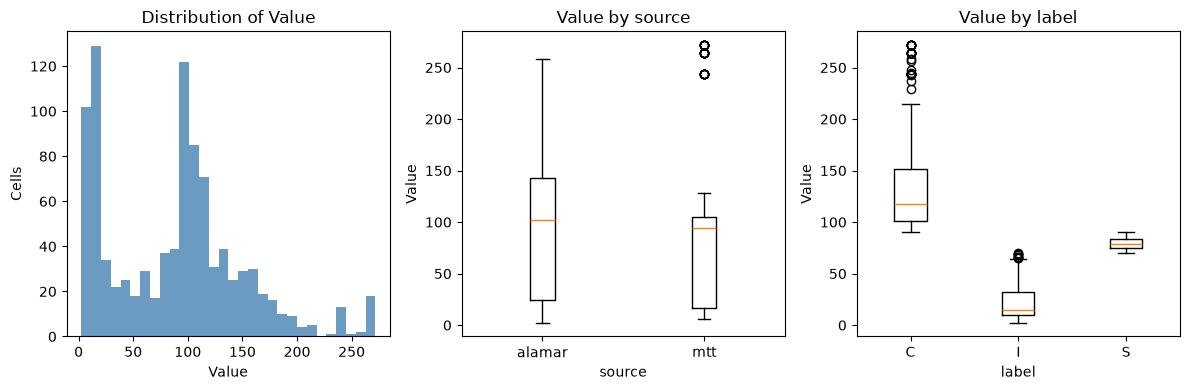

In [ ]:
no_na_values = df_filtered_no_na["Value"]
print("Number of unique Value measurements:", no_na_values.nunique())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(no_na_values, bins=30, color="steelblue", alpha=0.8)
axes[0].set(xlabel="Value", ylabel="Cells", title="Distribution of Value")
value_by_source = [
    no_na_values[df_filtered_no_na["source"] == label]
    for label in sorted(df_filtered_no_na["source"].unique())
]
axes[1].boxplot(
    value_by_source, tick_labels=sorted(df_filtered_no_na["source"].unique())
)
axes[1].set(xlabel="source", ylabel="Value", title="Value by source")
value_by_test = [
    no_na_values[df_filtered_no_na["label"] == label]
    for label in sorted(df_filtered_no_na["label"].unique())
]
axes[2].boxplot(value_by_test, tick_labels=sorted(df_filtered_no_na["label"].unique()))
axes[2].set(xlabel="label", ylabel="Value", title="Value by label")
plt.tight_layout()

The distribution of value seems to be different both for different sources and labels, with more separation noticable for labels.

In [ ]:
contingency_table = pd.crosstab(all_sources["source"], all_sources["label"])
print(contingency_table)

label        C      I    S
source                    
alamar     307    230   16
chroma       4      5    4
jimt     10464  11384    0
mtt        235    136   58
study18    581    223  198


`S` label is generally underrepresented, doesnt exist for `jimt` at all. `chroma` source containes very small amount of samples compared to the others. `jimt` source dominates the dataset.

Also checking for duplicates:

In [157]:
num_duplicates = all_sources.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 1


In [158]:
duplicates_df = all_sources[all_sources.duplicated(keep=False)]
print(duplicates_df)

        source label  Value  vgg_0  vgg_1    vgg_2  vgg_3     vgg_4  vgg_5  \
23655  study18     I    NaN    0.0    0.0  0.26289    0.0  0.722861    0.0   
23656  study18     I    NaN    0.0    0.0  0.26289    0.0  0.722861    0.0   

       vgg_6  ...  vgg_502  vgg_503   vgg_504   vgg_505   vgg_506   vgg_507  \
23655    0.0  ...      0.0      0.0  0.170863  2.528229  1.255248  0.248096   
23656    0.0  ...      0.0      0.0  0.170863  2.528229  1.255248  0.248096   

       vgg_508  vgg_509   vgg_510  vgg_511  
23655      0.0      0.0  0.544201      0.0  
23656      0.0      0.0  0.544201      0.0  

[2 rows x 515 columns]


In [159]:
num_duplicates_vgg = all_sources[vgg_columns].duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 1


Removing duplicated row. Previous stats for value aren't affected, nonly crosstab is, -1 from `study18` source and `I` label.

In [160]:
all_sources_cleaned = all_sources.drop_duplicates()

In [ ]:
print(
    "Fraction of zero entries in the vgg columns:",
    round(float((all_sources_cleaned[vgg_columns] == 0).to_numpy().mean()), 3),
)

Fraction of zero entries in the vgg columns: 0.413


### PCA diagnostic

Standardization is required for vgg columns, as we saw they definitely have different scales, and they don't have direct biological meanings (in which case standardization could hurt).

In [162]:
embedding_scaler = StandardScaler()
X_embedding_scaled = embedding_scaler.fit_transform(all_sources_cleaned[vgg_columns])
embedding_pca = PCA(n_components=30, svd_solver="randomized", random_state=RANDOM_STATE)
X_embedding_pca = embedding_pca.fit_transform(X_embedding_scaled)
X_embedding_pca

array([[  0.05309916,   8.32287845, -17.80286797, ...,   2.37498303,
          1.65215667,  -0.79196525],
       [ -0.0876887 ,  13.6031042 , -20.37658051, ...,  -2.24522931,
         -1.31573584,  -0.16524242],
       [  1.46403586,   9.75727576, -17.44942386, ...,   0.99368669,
          1.66166029,  -3.15541135],
       ...,
       [ -7.73958725,   5.01695656,  -1.58669705, ...,   0.63663012,
         -1.99936042,   1.64090424],
       [ -7.6254055 ,   3.76351384,  -2.614815  , ...,   1.87588481,
         -0.83259056,   0.86265924],
       [ -8.65077565,   3.5041617 ,  -1.0965678 , ...,   0.77644265,
         -2.26142372,   0.19383462]], shape=(23844, 30))

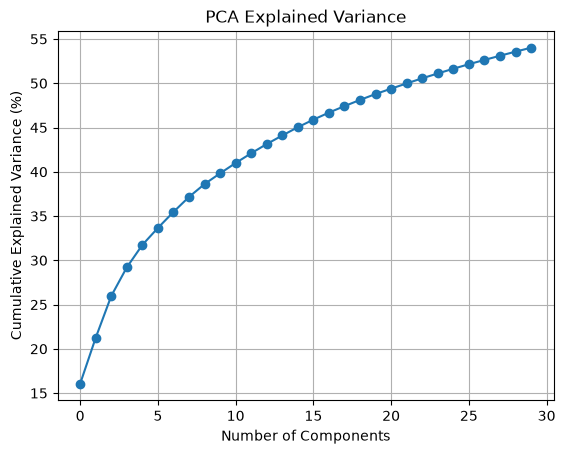

In [ ]:
plt.plot(np.cumsum(embedding_pca.explained_variance_ratio_) * 100, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

Not much variance explained by Principal components, which would limit their usage for modelling

Checking how different sources look like (compared between each other, max 100 samples per source) on PCA plot.

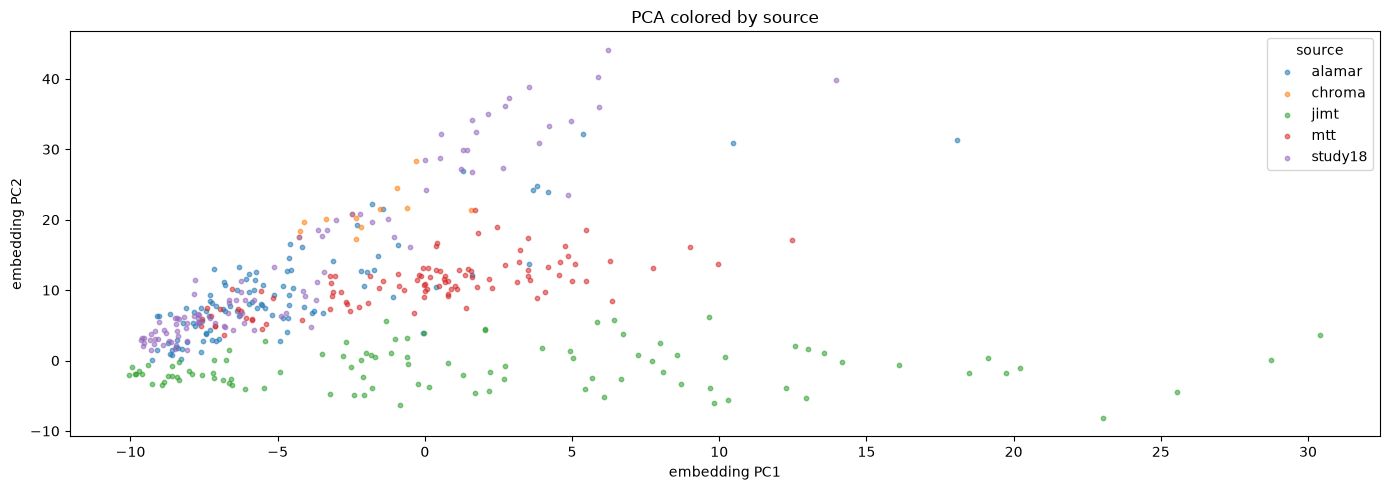

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
for label in sorted(all_sources_cleaned["source"].unique()):
    mask = all_sources_cleaned["source"] == label
    rng = np.random.default_rng(seed=RANDOM_STATE)
    random_100 = rng.choice(
        X_embedding_pca[mask, :], size=min(100, mask.sum()), replace=False
    )
    axes.scatter(random_100[:, 0], random_100[:, 1], s=10, alpha=0.55, label=label)
axes.set(xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by source")
axes.legend(title="source")
plt.tight_layout()

PC2 seems to separate well `jimt` from the other sources. On PC1 slight there seems to be slight separation between `study18` + `alamar` (both located more to the left) and `chroma` +`mtt`(both shifted more to the right).

Separate view, to see possible outliers ot subclasses inside the `source` field.

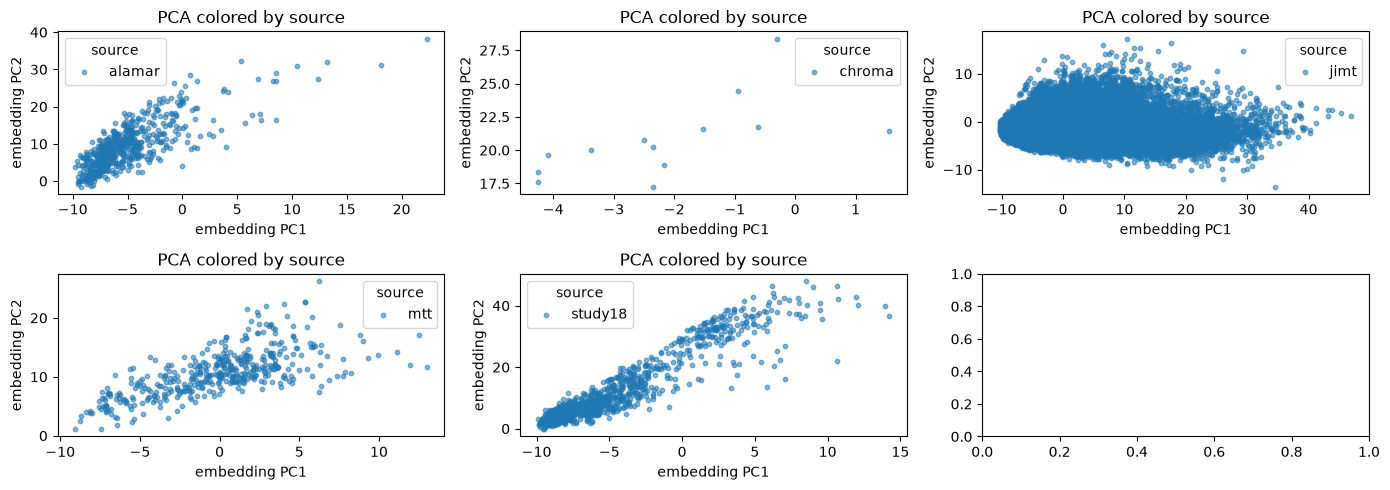

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 5))
for i, label in enumerate(sorted(all_sources_cleaned["source"].unique())):
    mask = all_sources_cleaned["source"] == label
    rng = np.random.default_rng(seed=RANDOM_STATE)
    axes[i // 3][i % 3].scatter(
        X_embedding_pca[mask, 0],
        X_embedding_pca[mask, 1],
        s=10,
        alpha=0.55,
        label=label,
    )
    axes[i // 3][i % 3].set(
        xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by source"
    )
    axes[i // 3][i % 3].legend(title="source")
plt.tight_layout()

No clear substructures seen in sources.

Doing the same for label column.

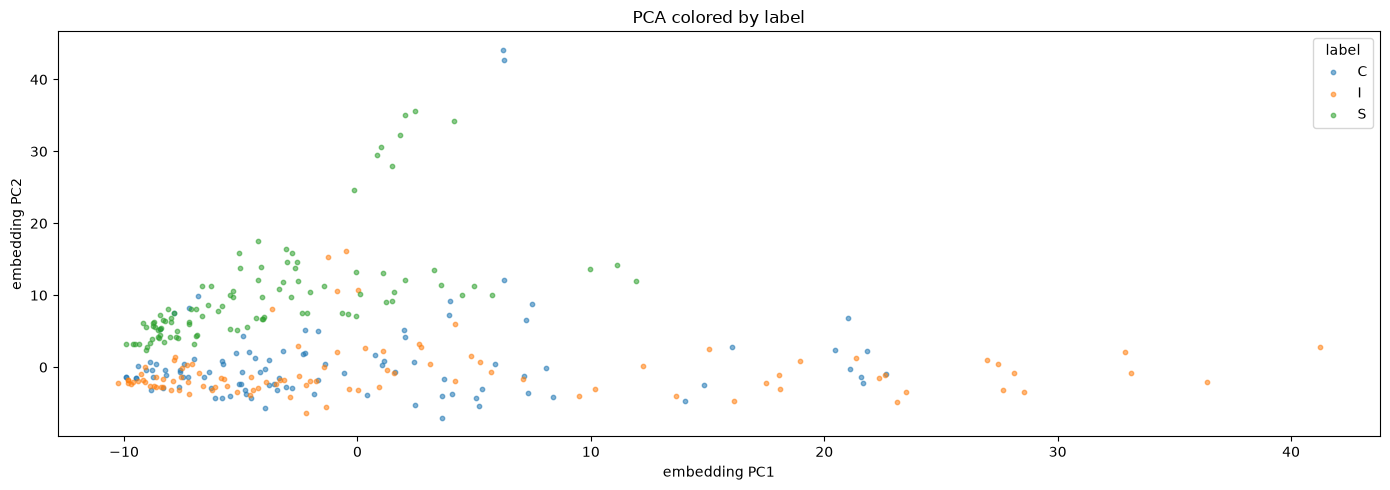

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
for label in sorted(all_sources_cleaned["label"].unique()):
    mask = all_sources_cleaned["label"] == label
    rng = np.random.default_rng(seed=RANDOM_STATE)
    random_100 = rng.choice(
        X_embedding_pca[mask, :], size=min(100, mask.sum()), replace=False
    )
    axes.scatter(random_100[:, 0], random_100[:, 1], s=10, alpha=0.55, label=label)
axes.set(xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by label")
axes.legend(title="label")
plt.tight_layout()

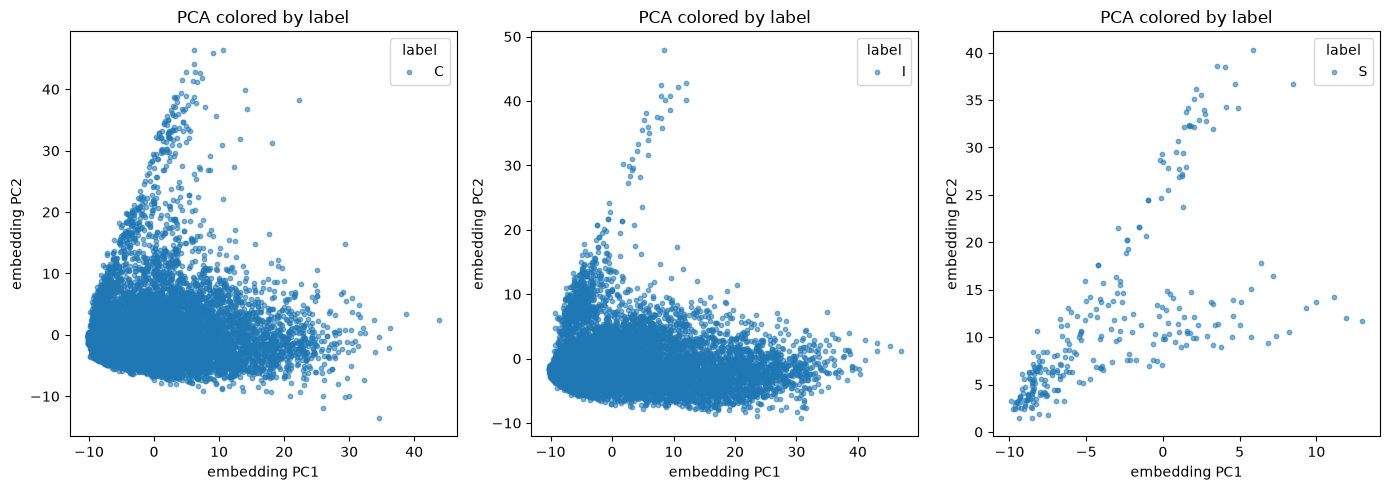

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, label in enumerate(sorted(all_sources_cleaned["label"].unique())):
    mask = all_sources_cleaned["label"] == label
    rng = np.random.default_rng(seed=RANDOM_STATE)
    axes[i % 3].scatter(
        X_embedding_pca[mask, 0],
        X_embedding_pca[mask, 1],
        s=10,
        alpha=0.55,
        label=label,
    )
    axes[i % 3].set(
        xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by label"
    )
    axes[i % 3].legend(title="label")
plt.tight_layout()

All labels seem to be  following v-like patterns (likely due to `source` column hiding different subclasses in it). PC2 seems to separate `S` label from the other 2.

Let's also check PCA for samples where `Value` is present. and any dependencies it might reveal

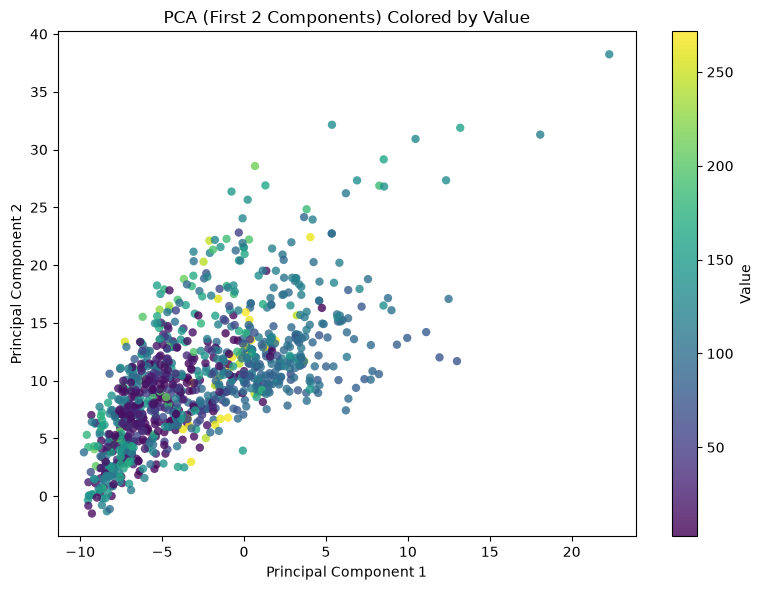

In [ ]:
all_sources_cleaned = all_sources_cleaned.reset_index(drop=True)
valid_mask = all_sources_cleaned["Value"].notna()

pc1 = X_embedding_pca[valid_mask, 0]
pc2 = X_embedding_pca[valid_mask, 1]
values = all_sources_cleaned.loc[valid_mask, "Value"].values

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pc1,
    pc2,
    c=values,
    cmap="viridis",
    alpha=0.8,
    edgecolors="none",
)

cbar = plt.colorbar(scatter)
cbar.set_label("Value")

plt.title("PCA (First 2 Components) Colored by Value")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

Low values seem to form into cluster, but apart from that no clear dependencyis visible

### t-SNE

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=RANDOM_STATE,
)

X_tsne = tsne.fit_transform(X_embedding_scaled)
X_tsne

array([[-40.923283,  59.779476],
       [-42.852654,  60.21772 ],
       [-41.55164 ,  57.462555],
       ...,
       [  8.581521,  60.702755],
       [  6.971491,  60.680943],
       [  8.091484,  60.599804]], shape=(23844, 2), dtype=float32)

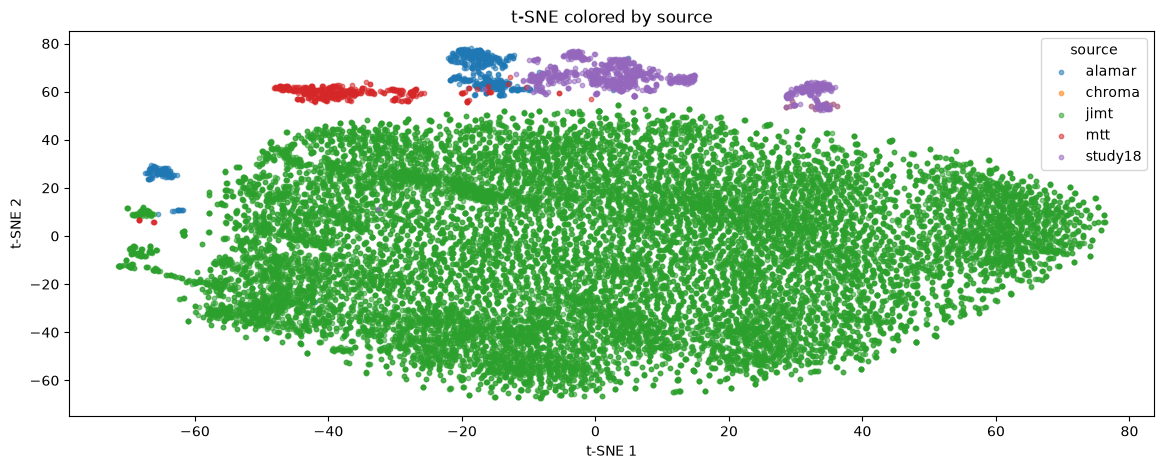

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
for label in sorted(np.unique(all_sources_cleaned["source"])):
    mask = all_sources_cleaned["source"] == label
    axes.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.55, label=label)
axes.set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="t-SNE colored by source")
axes.legend(title="source")

Better visibility of the minority source `chroma`

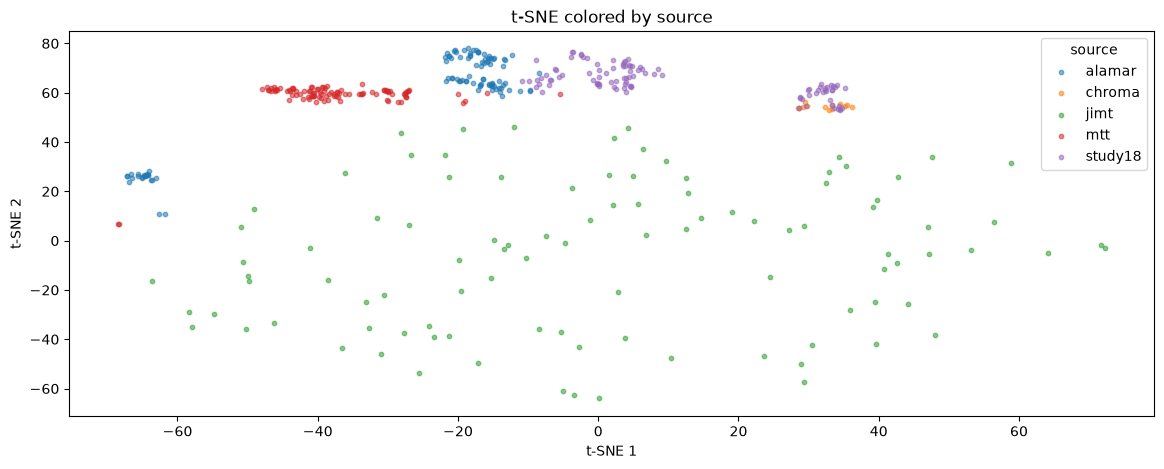

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
for label in sorted(np.unique(all_sources_cleaned["source"])):
    mask = all_sources_cleaned["source"] == label
    rng = np.random.default_rng(seed=RANDOM_STATE)
    random_100 = rng.choice(X_tsne[mask, :], size=min(100, mask.sum()), replace=False)
    axes.scatter(random_100[:, 0], random_100[:, 1], s=10, alpha=0.55, label=label)
axes.set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="t-SNE colored by source")
axes.legend(title="source")

t-SNE shows almost perfect clustering on source level, with minor outliers. It alo reveals presence of subclusters for everything except jimt, which might correspond to label value 

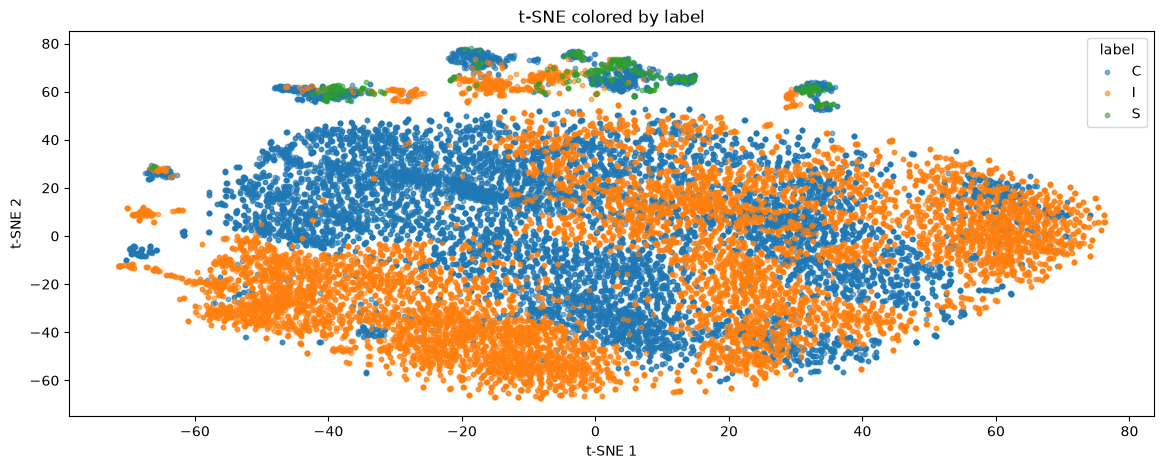

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
for label in sorted(np.unique(all_sources_cleaned["label"])):
    mask = all_sources_cleaned["label"] == label
    axes.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.55, label=label)
axes.set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="t-SNE colored by label")
axes.legend(title="label")

Separation with regard to label is much worse, `source` brings much stronger signal, pointing again to batch-effect.

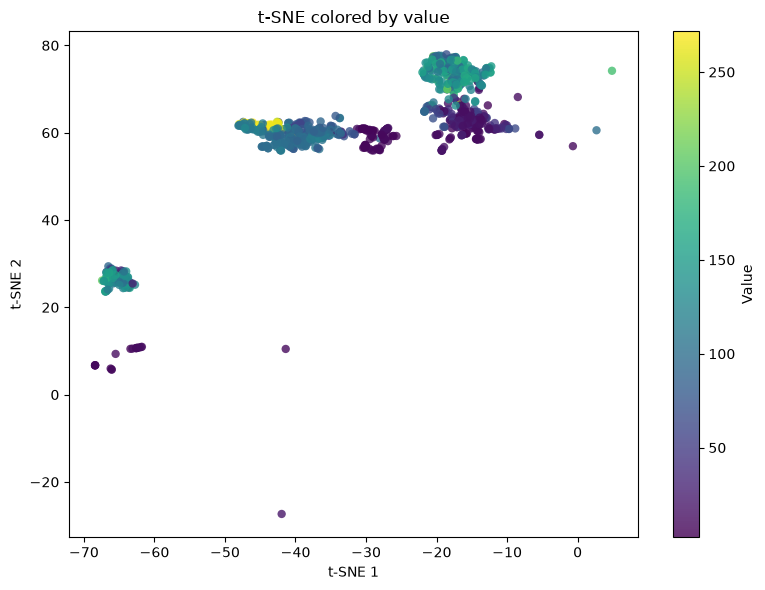

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[valid_mask.values, 0],
    X_tsne[valid_mask.values, 1],
    c=values,
    cmap="viridis",
    alpha=0.8,
    edgecolors="none",
)

cbar = plt.colorbar(scatter)
cbar.set_label("Value")

plt.title("t-SNE colored by value")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

Again, as in PCA, we see cluster of only low values, but for other clusters it is hard to say that they are following some rule. 

Perplexity effect check:

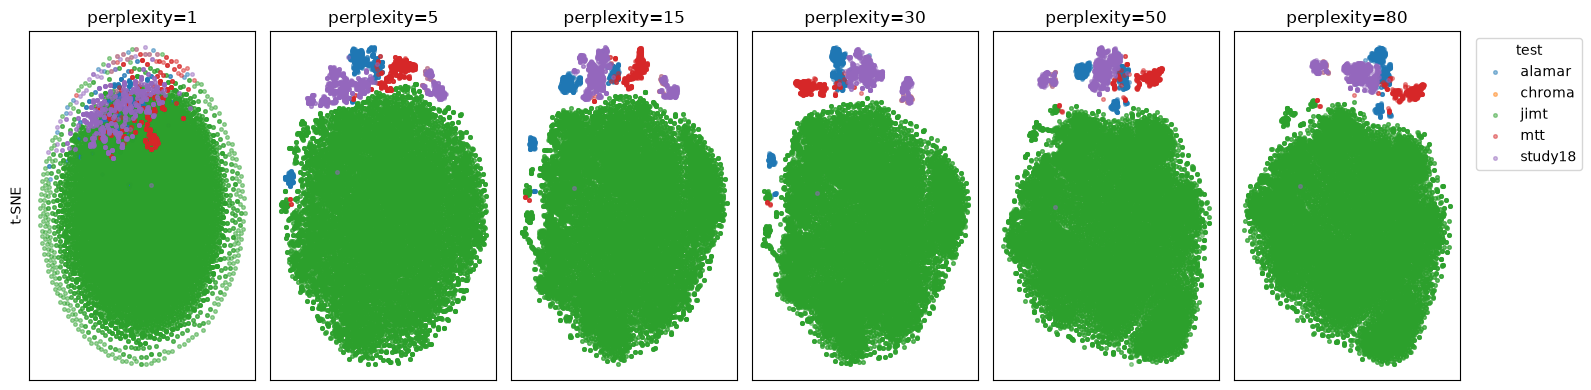

In [ ]:
perplexities = [1, 5, 15, 30, 50, 80]
fig, axes = plt.subplots(1, len(perplexities), figsize=(16, 4))
for ax, perplexity in zip(axes, perplexities):
    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=750,
        random_state=RANDOM_STATE,
    ).fit_transform(X_embedding_scaled)
    for label in sorted(np.unique(all_sources_cleaned["source"])):
        mask = all_sources_cleaned["source"] == label
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=7, alpha=0.45, label=label)
    ax.set_title(f"perplexity={perplexity}")
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].set_ylabel("t-SNE")
axes[-1].legend(title="test", bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()


At around perplexity level of 5 clusters are already  well-defined and visible, but the best ones seem to be 15 or 30, further levels seem to bring different source levels too close and loose pattern of subclusters forming for one source.

### UMAP

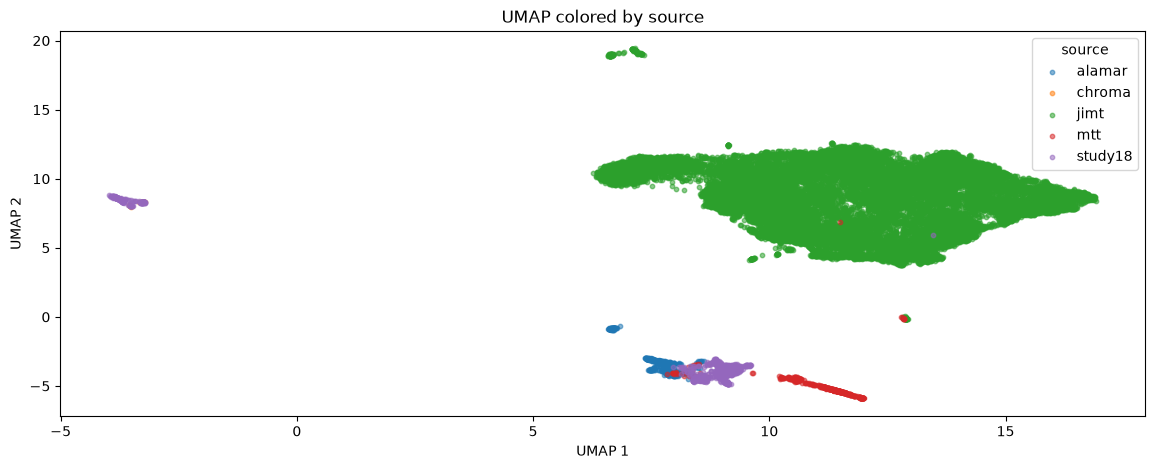

In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE, n_jobs=1)

X_umap = reducer.fit_transform(X_embedding_scaled)
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
for label in sorted(np.unique(all_sources_cleaned["source"])):
    mask = all_sources_cleaned["source"] == label
    axes.scatter(X_umap[mask, 0], X_umap[mask, 1], s=10, alpha=0.55, label=label)
axes.set(xlabel="UMAP 1", ylabel="UMAP 2", title="UMAP colored by source")
axes.legend(title="source")


Source separation seems worse than for t-SNE. Trying other hyperparameters was taking to long, so going with the first ones

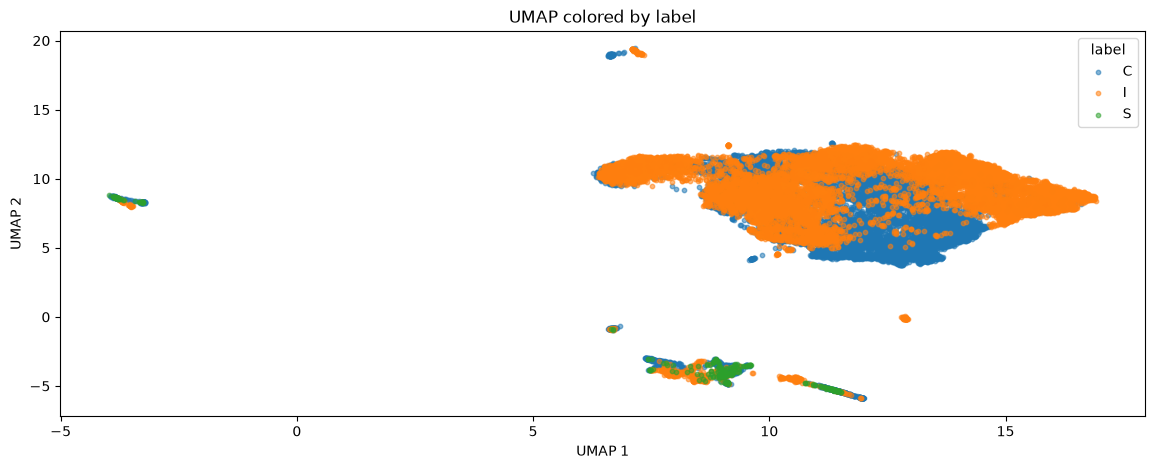

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
for label in sorted(np.unique(all_sources_cleaned["label"])):
    mask = all_sources_cleaned["label"] == label
    axes.scatter(X_umap[mask, 0], X_umap[mask, 1], s=10, alpha=0.55, label=label)
axes.set(xlabel="UMAP 1", ylabel="UMAP 2", title="UMAP colored by label")
axes.legend(title="label")


As before, label separation is poor, compared to source separation

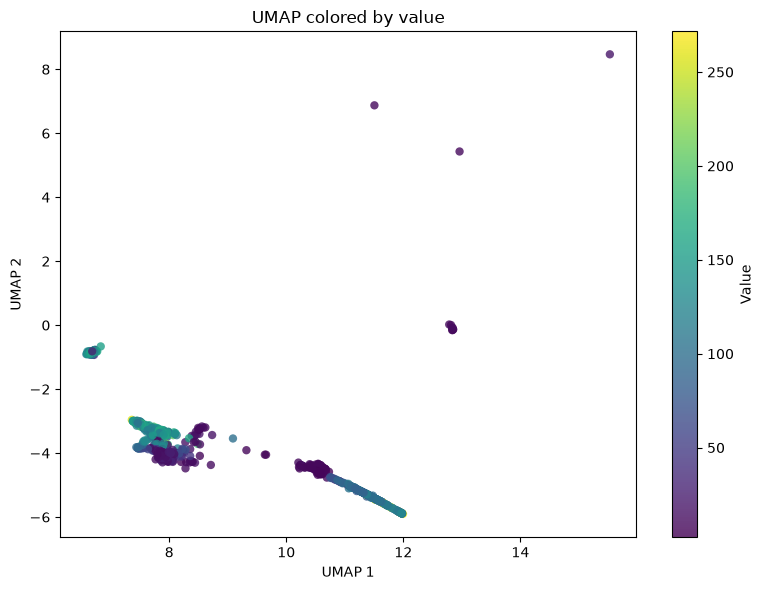

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_umap[valid_mask.values, 0],
    X_umap[valid_mask.values, 1],
    c=values,
    cmap="viridis",
    alpha=0.8,
    edgecolors="none",
)

cbar = plt.colorbar(scatter)
cbar.set_label("Value")

plt.title("UMAP colored by value")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()
plt.show()

Here value separation seems even poorer than for the previous 2 methods (even though the previous 2 are also not good)

### PCA / t-SNE / UMAP comparison

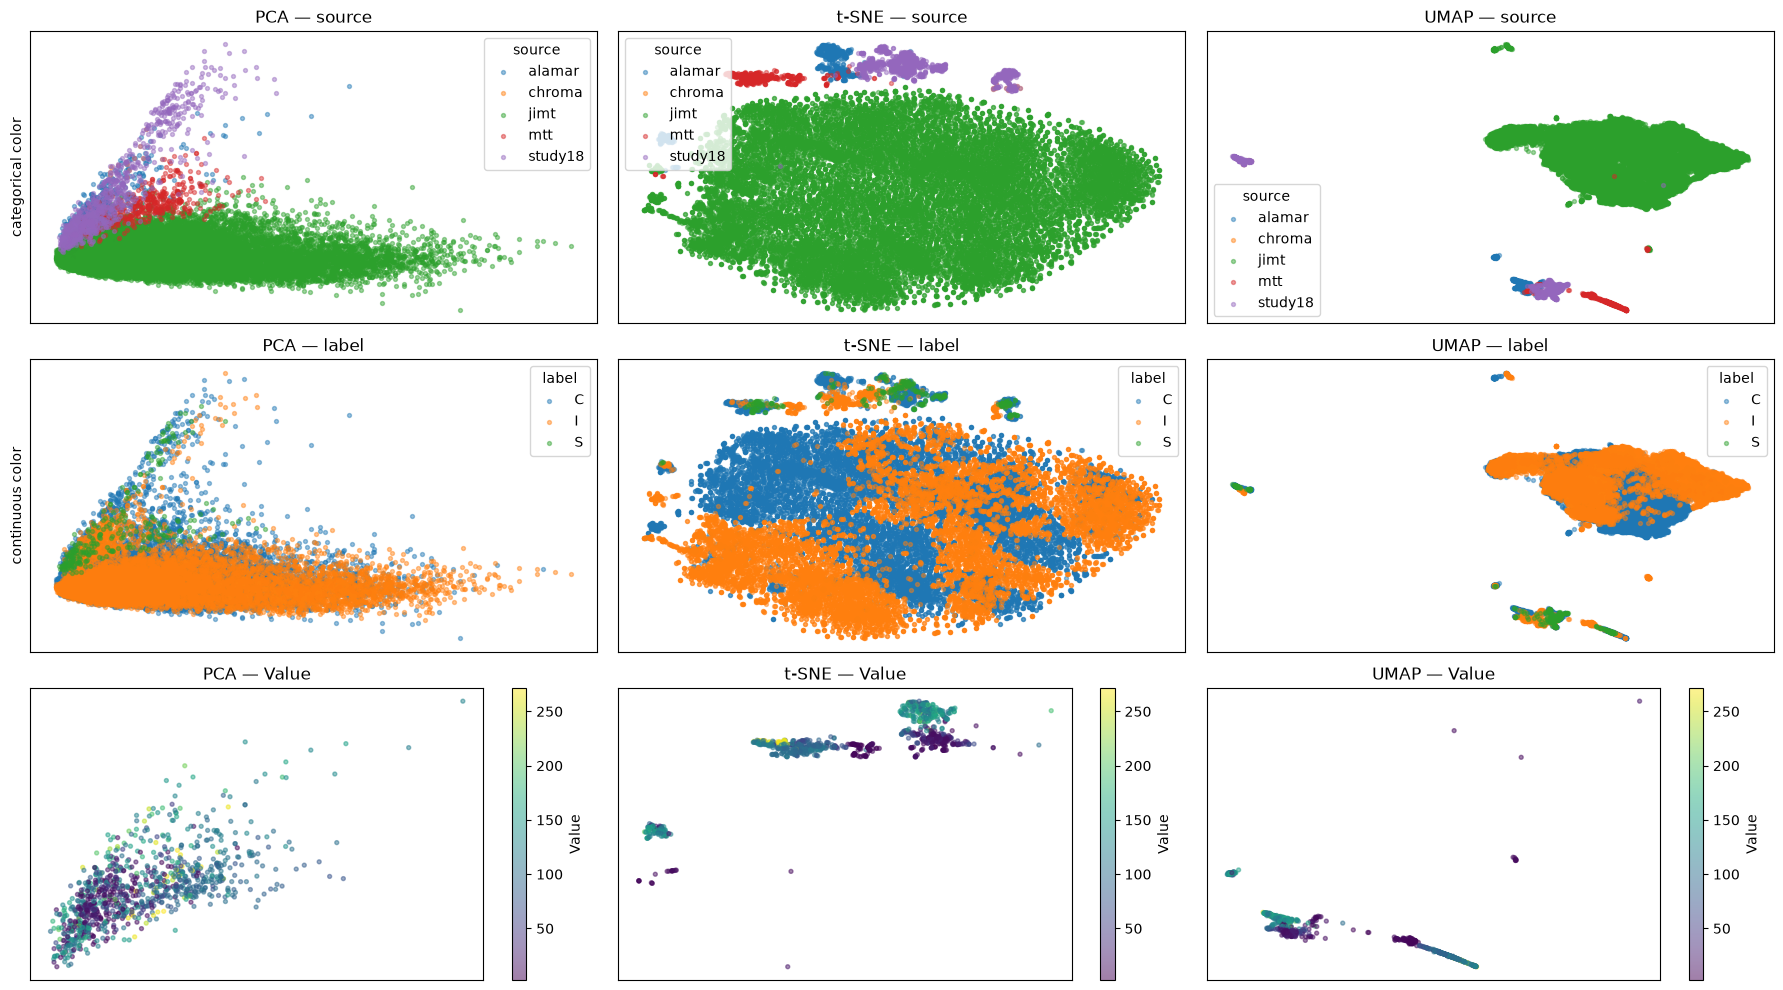

In [ ]:
comparison_embeddings = [X_embedding_pca[:, :2], X_tsne, X_umap]
comparison_titles = ["PCA", "t-SNE", "UMAP"]
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
for ax, embedding, title in zip(axes[0], comparison_embeddings, comparison_titles):
    for label in sorted(np.unique(all_sources_cleaned["source"])):
        mask = all_sources_cleaned["source"] == label
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=8, alpha=0.45, label=label)
    ax.set_title(f"{title} — source")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(title="source")
for ax, embedding, title in zip(axes[1], comparison_embeddings, comparison_titles):
    for label in sorted(np.unique(all_sources_cleaned["label"])):
        mask = all_sources_cleaned["label"] == label
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=8, alpha=0.45, label=label)
    ax.set_title(f"{title} — label")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(title="label")
for ax, embedding, title in zip(axes[2], comparison_embeddings, comparison_titles):
    value_plot = ax.scatter(
        embedding[valid_mask.values, 0],
        embedding[valid_mask.values, 1],
        c=values,
        cmap="viridis",
        s=8,
        alpha=0.5,
    )
    ax.set_title(f"{title} — Value")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(value_plot, ax=ax, label="Value")
axes[0, 0].set_ylabel("categorical color")
axes[1, 0].set_ylabel("continuous color")
plt.tight_layout()


Label and Value separation for all 3 methods is bad, the batch effect (`source` column) seems to domminate the biological signal, as in all 3 methods the graphs show some separation with regard to `source`. The best separation (in my opinion) is produced by t-SNE.

### Train / validation / test split

In [ ]:
X = all_sources_cleaned[vgg_columns]
y = all_sources_cleaned["label"]
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=0.25,
    stratify=y_train_valid,
    random_state=RANDOM_STATE,
)
target_names = dict(enumerate(all_sources_cleaned.label))
display(
    y_train.value_counts(normalize=True)
    .rename(index=target_names)
    .to_frame("proportion")
)

,proportion
label,
I,0.502237
C,0.486160
S,0.011604


### KNN

Metrics:


{'accuracy': 0.891172153491298,
 'balanced_accuracy': 0.7192616458008447,
 'macro_f1': 0.7361052874030781}

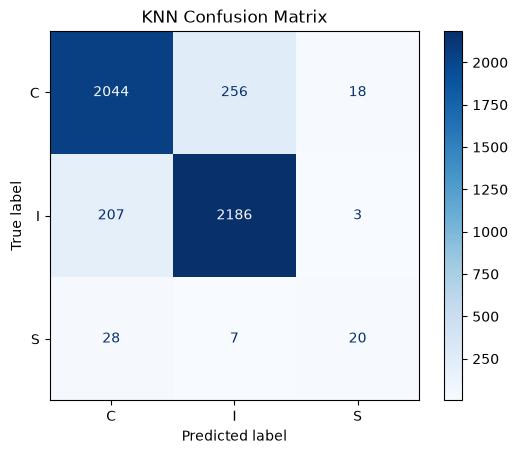

In [ ]:
def classifier_metrics(model, X_eval, y_eval):
    predictions = model.predict(X_eval)

    metrics = {
        "accuracy": accuracy_score(y_eval, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "macro_f1": f1_score(y_eval, predictions, average="macro"),
    }

    cm = confusion_matrix(y_eval, predictions)

    return metrics, cm


knn = Pipeline(
    [("scale", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))]
)
knn.fit(X_train, y_train)

scaled_knn_metrics, cm = classifier_metrics(knn, X_valid, y_valid)

print("Metrics:")
display(scaled_knn_metrics)

disp = ConfusionMatrixDisplay.from_estimator(knn, X_valid, y_valid, cmap=plt.cm.Blues)
plt.title("KNN Confusion Matrix")
plt.show()

Trying manual selection of `k` too:

,k,accuracy,balanced_accuracy,macro_f1,cm
0,1,0.920319,0.786304,0.774103,"[[2115, 174, 29], [143, 2246, 7], [22, 5, 28]]"
1,3,0.907947,0.766089,0.771838,"[[2080, 218, 20], [167, 2224, 5], [25, 4, 26]]"
2,5,0.891172,0.719262,0.736105,"[[2044, 256, 18], [207, 2186, 3], [28, 7, 20]]"
3,7,0.888446,0.717462,0.735692,"[[2046, 255, 17], [222, 2171, 3], [27, 8, 20]]"
4,11,0.873768,0.672008,0.697984,"[[2006, 302, 10], [245, 2147, 4], [34, 7, 14]]"
5,21,0.858251,0.655576,0.684661,"[[1960, 350, 8], [273, 2120, 3], [36, 6, 13]]"


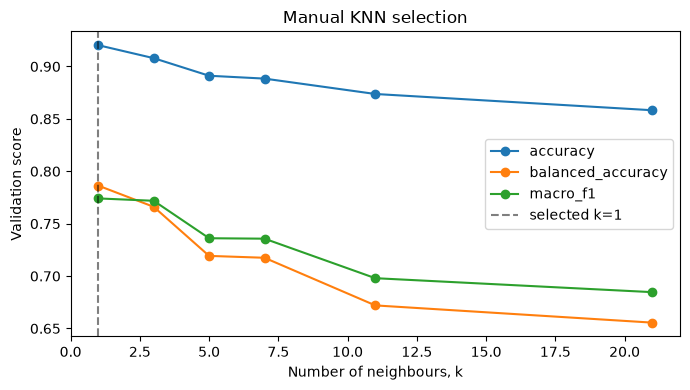

In [ ]:
k_values = [1, 3, 5, 7, 11, 21]

knn_results = []
for k in k_values:
    candidate = Pipeline(
        [("scale", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=k))]
    )
    candidate.fit(X_train, y_train)
    metrics = classifier_metrics(candidate, X_valid, y_valid)
    knn_results.append({"k": k, **metrics[0], "cm": metrics[1]})

knn_results = pd.DataFrame(knn_results)
display(knn_results)
best_k = int(knn_results.loc[knn_results["macro_f1"].idxmax(), "k"])

plt.figure(figsize=(7, 4))
for metric in ["accuracy", "balanced_accuracy", "macro_f1"]:
    plt.plot(knn_results["k"], knn_results[metric], marker="o", label=metric)
plt.axvline(
    best_k, color="black", linestyle="--", alpha=0.5, label=f"selected k={best_k}"
)
plt.xlabel("Number of neighbours, k")
plt.ylabel("Validation score")
plt.title("Manual KNN selection")
plt.legend()
plt.tight_layout()
plt.show()


Using only 1 neighbour for KNN seems to be the best approach. This makes sense, as we saw label separation is very pour for all dimensionality reduction techniques, samples are closer when they are from the same source, not when they have the same lable. Most likely signal from `source` is what can be catched by using more neighbours, and that is why the metrics aren't improving when more neighbours are added.

### Linear SVM

,linear SVM
accuracy,0.841267
balanced_accuracy,0.673844
macro_f1,0.690180


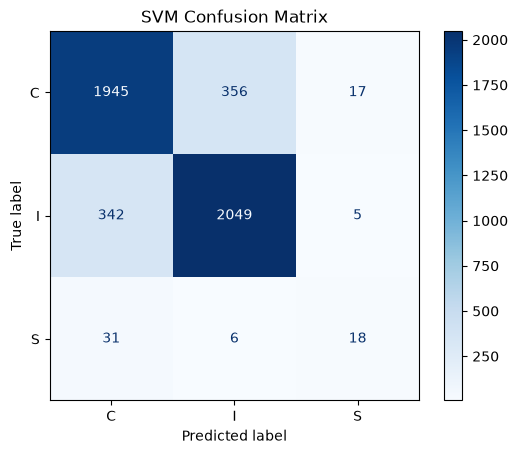

In [ ]:
svm_linear = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model", SVC(kernel="linear", C=0.01)),
    ]
)
svm_linear.fit(X_train, y_train)
linear_svm_metrics = classifier_metrics(svm_linear, X_valid, y_valid)
display(pd.Series(linear_svm_metrics[0], name="linear SVM").to_frame())
disp = ConfusionMatrixDisplay(
    confusion_matrix=linear_svm_metrics[1], display_labels=svm_linear.classes_
)

disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")
plt.show()


### RBF and polynomial SVM kernels

,RBF SVM
accuracy,0.884043
balanced_accuracy,0.626463
macro_f1,0.643236


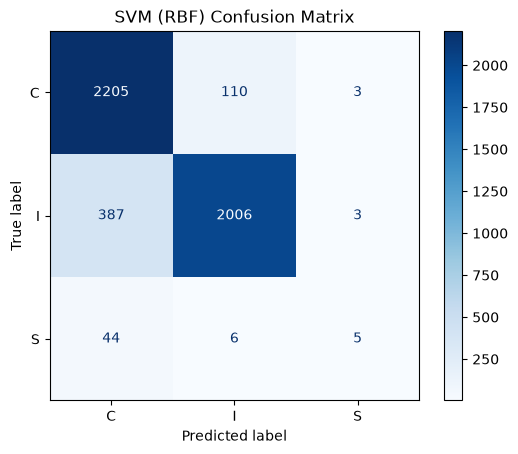

In [ ]:
svm_rbf = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma=0.01)),
    ]
)
svm_rbf.fit(X_train, y_train)
rbf_svm_metrics = classifier_metrics(svm_rbf, X_valid, y_valid)
display(pd.Series(rbf_svm_metrics[0], name="RBF SVM").to_frame())
disp = ConfusionMatrixDisplay(
    confusion_matrix=rbf_svm_metrics[1], display_labels=svm_rbf.classes_
)

disp.plot(cmap=plt.cm.Blues)
plt.title("SVM (RBF) Confusion Matrix")
plt.show()


,Poly SVM
accuracy,0.900398
balanced_accuracy,0.749401
macro_f1,0.754549


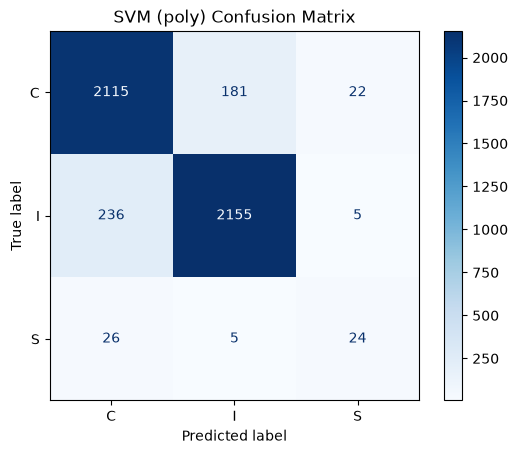

In [ ]:
poly_rbf = Pipeline(
    [
        ("scale", StandardScaler()),
        ("model", SVC(kernel="poly", C=10, degree=3)),
    ]
)
poly_rbf.fit(X_train, y_train)
poly_svm_metrics = classifier_metrics(poly_rbf, X_valid, y_valid)
display(pd.Series(poly_svm_metrics[0], name="Poly SVM").to_frame())
disp = ConfusionMatrixDisplay(
    confusion_matrix=poly_svm_metrics[1], display_labels=poly_rbf.classes_
)

disp.plot(cmap=plt.cm.Blues)
plt.title("SVM (poly) Confusion Matrix")
plt.show()

### Manual SVM hyperparameter comparison

,C,gamma,accuracy,balanced_accuracy,macro_f1,cm
10,10.0,scale,0.924303,0.771271,0.784212,"[[2134, 168, 16], [142, 2249, 5], [26, 4, 25]]"
11,10.0,0.001,0.912770,0.751646,0.762089,"[[2106, 193, 19], [167, 2224, 5], [27, 5, 23]]"
16,100.0,0.001,0.910254,0.755865,0.761122,"[[2099, 196, 23], [174, 2218, 4], [26, 5, 24]]"
15,100.0,scale,0.915077,0.735426,0.756519,"[[2109, 194, 15], [158, 2235, 3], [29, 6, 20]]"
5,1.0,scale,0.904802,0.681204,0.715693,"[[2102, 212, 4], [193, 2201, 2], [37, 6, 12]]"
12,10.0,0.01,0.892850,0.656015,0.685249,"[[2210, 105, 3], [355, 2039, 2], [40, 6, 9]]"
17,100.0,0.01,0.892221,0.655593,0.684826,"[[2209, 106, 3], [357, 2037, 2], [40, 6, 9]]"
6,1.0,0.001,0.880897,0.641363,0.669810,"[[2039, 276, 3], [241, 2154, 1], [41, 6, 8]]"
7,1.0,0.01,0.884043,0.626463,0.643236,"[[2205, 110, 3], [387, 2006, 3], [44, 6, 5]]"
0,0.1,scale,0.838121,0.565386,0.561991,"[[1991, 327, 0], [390, 2006, 0], [48, 7, 0]]"


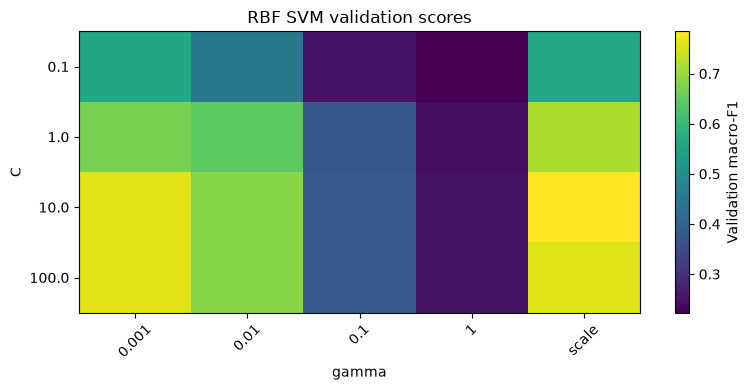

In [ ]:
C_values = [0.1, 1, 10, 100]
gamma_values = ["scale", 0.001, 0.01, 0.1, 1]

svm_validation_results = []
for C in C_values:
    for gamma in gamma_values:
        candidate = Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", SVC(kernel="rbf", C=C, gamma=gamma)),
            ]
        )
        candidate.fit(X_train, y_train)
        metrics = classifier_metrics(candidate, X_valid, y_valid)
        svm_validation_results.append(
            {"C": C, "gamma": str(gamma), **metrics[0], "cm": metrics[1]}
        )

svm_validation_results = pd.DataFrame(svm_validation_results)
display(svm_validation_results.sort_values("macro_f1", ascending=False).head(10))
best_svm_row = svm_validation_results.loc[svm_validation_results["macro_f1"].idxmax()]
best_svm_C = float(best_svm_row["C"])
best_svm_gamma = best_svm_row["gamma"]
if best_svm_gamma not in {"scale", "auto"}:
    best_svm_gamma = float(best_svm_gamma)

score_grid = svm_validation_results.pivot(index="C", columns="gamma", values="macro_f1")
plt.figure(figsize=(8, 4))
plt.imshow(
    score_grid,
    aspect="auto",
    cmap="viridis",
    vmin=score_grid.min().min(),
    vmax=score_grid.max().max(),
)
plt.colorbar(label="Validation macro-F1")
plt.xticks(range(len(score_grid.columns)), score_grid.columns, rotation=45)
plt.yticks(range(len(score_grid.index)), score_grid.index)
plt.xlabel("gamma")
plt.ylabel("C")
plt.title("RBF SVM validation scores")
plt.tight_layout()
plt.show()


Best value obtained for `C=10` and `gamma=scale`

### KNN/SVM + PCA

Number of PCA components retained: 343


,PCA + RBF SVM
accuracy,0.920738
balanced_accuracy,0.768869
macro_f1,0.785017


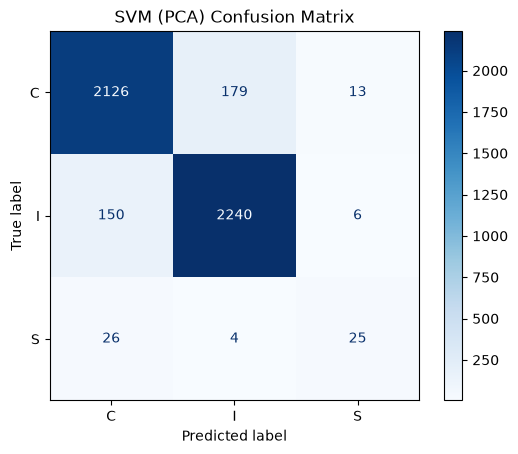

In [ ]:
svm_pca = Pipeline(
    [
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", SVC(kernel="rbf", C=best_svm_C, gamma=best_svm_gamma)),
    ]
)
svm_pca.fit(X_train, y_train)
pca_svm_metrics = classifier_metrics(svm_pca, X_valid, y_valid)
print("Number of PCA components retained:", svm_pca.named_steps["pca"].n_components_)
display(pd.Series(pca_svm_metrics[0], name="PCA + RBF SVM").to_frame())
disp = ConfusionMatrixDisplay(
    confusion_matrix=pca_svm_metrics[1], display_labels=svm_pca.classes_
)

disp.plot(cmap=plt.cm.Blues)
plt.title("SVM (PCA) Confusion Matrix")
plt.show()


,model,n_features,accuracy,balanced_accuracy,macro_f1
0,raw KNN,512,0.948417,0.846752,0.831336
1,RBF SVM,512,0.935836,0.773109,0.796849
2,scaled KNN,512,0.936674,0.791397,0.794364
3,PCA + RBF SVM,345,0.929755,0.763088,0.787484
4,polynomial SVM,512,0.916544,0.748303,0.766845
5,linear SVM,512,0.845041,0.741560,0.737055


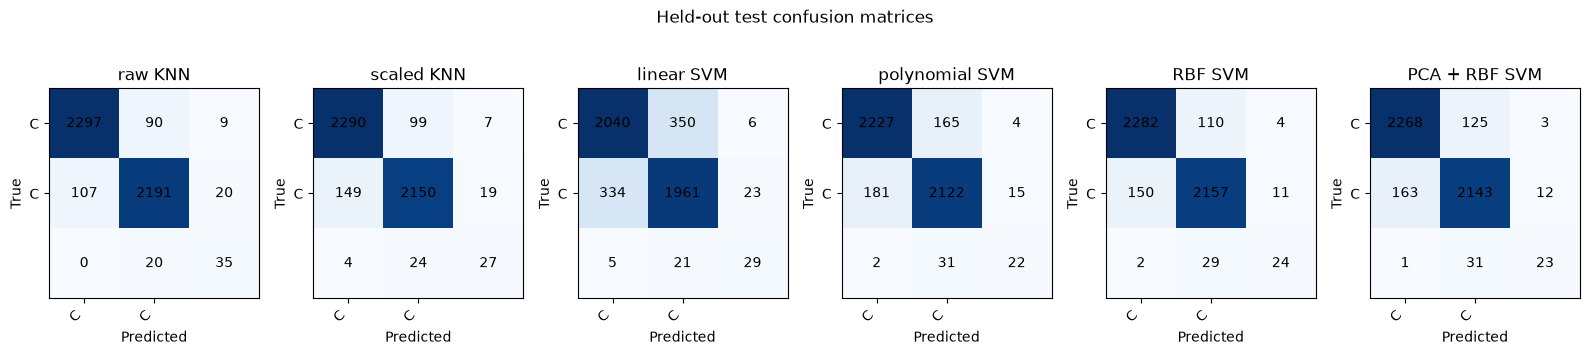

In [ ]:
models = {
    "raw KNN": KNeighborsClassifier(n_neighbors=best_k),
    "scaled KNN": Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=best_k)),
        ]
    ),
    "linear SVM": Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", SVC(kernel="linear", C=1)),
        ]
    ),
    "polynomial SVM": Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", SVC(kernel="poly", degree=3, C=1, gamma="scale", coef0=1)),
        ]
    ),
    "RBF SVM": Pipeline(
        [
            ("scale", StandardScaler()),
            ("model", SVC(kernel="rbf", C=best_svm_C, gamma=best_svm_gamma)),
        ]
    ),
    "PCA + RBF SVM": Pipeline(
        [
            ("scale", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", SVC(kernel="rbf", C=best_svm_C, gamma=best_svm_gamma)),
        ]
    ),
}

test_results = []
test_predictions = {}
for name, model in models.items():
    model.fit(X_train_valid, y_train_valid)
    predictions = model.predict(X_test)
    test_predictions[name] = predictions
    row = {
        "model": name,
        "n_features": model.named_steps["pca"].n_components_
        if hasattr(model, "named_steps") and "pca" in model.named_steps
        else X_train_valid.shape[1],
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "macro_f1": f1_score(y_test, predictions, average="macro"),
    }
    test_results.append(row)

test_results = pd.DataFrame(test_results).sort_values("macro_f1", ascending=False)
display(test_results.reset_index(drop=True))

fig, axes = plt.subplots(1, len(models), figsize=(16, 3.5))
for ax, (name, predictions) in zip(axes, test_predictions.items()):
    cm = confusion_matrix(y_test.values, predictions, labels=y_test.unique())
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1], [target_names[0], target_names[1]], rotation=45, ha="right")
    ax.set_yticks([0, 1], [target_names[0], target_names[1]])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for (row, col), value in np.ndenumerate(cm):
        ax.text(col, row, value, ha="center", va="center")
fig.suptitle("Held-out test confusion matrices")
plt.tight_layout()
plt.show()


Surprisingly raw KNN performs the best (better than the scaled one). It could be possible if some vgg components had high variance and are "responsible" specifically for label prediction, therefore not scaling them brings better results, as the component responsible for label is the one contributing todistance between samples the most.

### Clustering with K-means

As we want to use clustering for possible labels prediction, it makes sense to set `K` to 3 (the amount of labels we want to get)

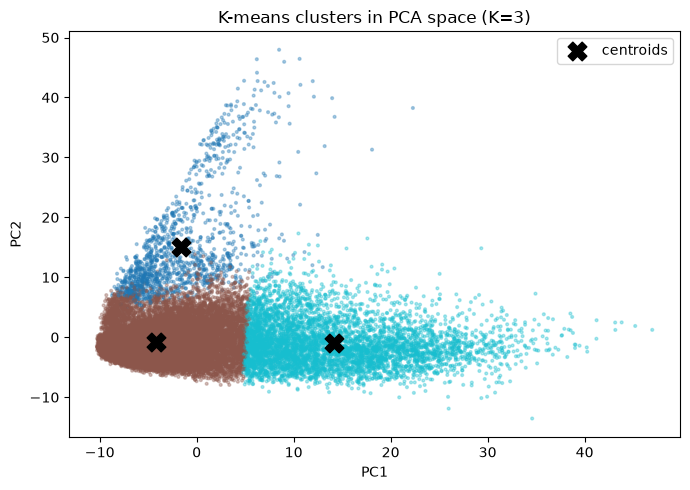

In [ ]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_embedding_pca)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_embedding_pca[:, 0],
    X_embedding_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=4,
    alpha=0.35,
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=180,
    c="black",
    label="centroids",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters in PCA space (K={n_clusters})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
contingency_table = pd.crosstab(cluster_labels, all_sources_cleaned["label"])
print(contingency_table)

label     C     I    S
row_0                 
0       705   444  178
1      8636  8476   98
2      2250  3057    0


None of the clusters corresponds can be said to correspond to one of the labels

Checking if clustering will catch technical signal from `source` column better:

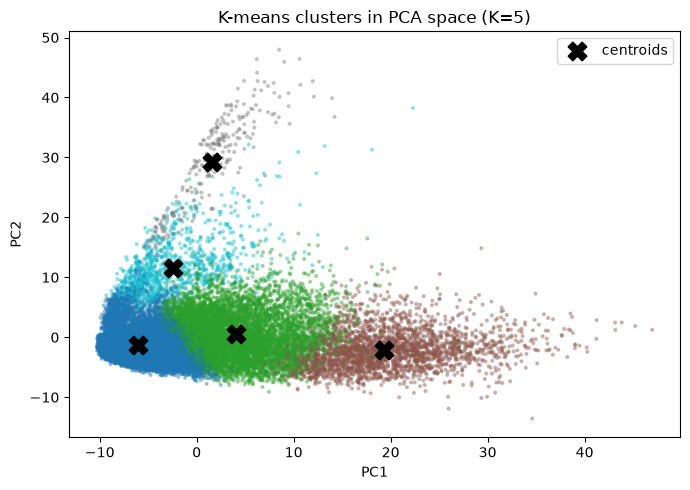

In [ ]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_embedding_pca)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_embedding_pca[:, 0],
    X_embedding_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=4,
    alpha=0.35,
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=180,
    c="black",
    label="centroids",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters in PCA space (K={n_clusters})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
contingency_table = pd.crosstab(cluster_labels, all_sources_cleaned["source"])
print(contingency_table)

source  alamar  chroma   jimt  mtt  study18
row_0                                      
0          165       0  12223   36      455
1            3       0   6868    1        2
2            0       0   2757    0        0
3            0      10      0    0      237
4          385       3      0  392      307


We can see that K-Means, as dimensionality reduction methods, is much better in detecting technical variations rather than true label in this case

We can also try accounting for technical variables, and then the amount of clusters should be 14 (3 for each source, except jimt which doesn't have `S` label)

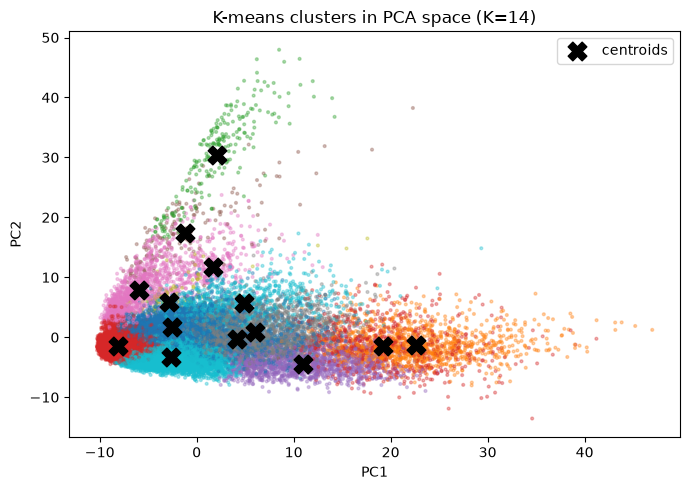

In [ ]:
n_clusters = 14
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_embedding_pca)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_embedding_pca[:, 0],
    X_embedding_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=4,
    alpha=0.35,
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=180,
    c="black",
    label="centroids",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters in PCA space (K={n_clusters})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
contingency_table = pd.crosstab(cluster_labels, all_sources_cleaned["source"])
print(contingency_table)

source  alamar  chroma  jimt  mtt  study18
row_0                                     
0            1       0  3035    2        1
1            0       0  1302    0        0
2            0       0  1216    0        0
3            0       9     0    0      218
4            0       0   741    0        0
5           57       0  6356    9       98
6            0       0  1475    0        0
7          137       0     0   11       23
8          354       4     0  113      659
9            3       0     0  291        1
10           0       0  2048    2        1
11           0       0   150    0        0
12           1       0  4745    1        0
13           0       0   780    0        0


In [ ]:
contingency_table = pd.crosstab(cluster_labels, all_sources_cleaned["label"])
print(contingency_table)

label     C     I    S
row_0                 
0      2217   822    0
1       666   636    0
2       257   959    0
3       146    35   46
4       361   380    0
5      2607  3900   13
6       623   852    0
7       157     6    8
8       483   492  155
9       218    23   54
10      974  1077    0
11       98    52    0
12     2113  2634    0
13      671   109    0


Even when tried to account for information about both classes, labels aren't clearly separated, there is no claster that can be associated at least with one of them

Let's also check what clustering the algorithm considers as the best one

In [ ]:
k_values = range(2, 9)
inertias = []
silhouettes = []
for k in k_values:
    candidate = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(X_embedding_pca)
    inertias.append(candidate.inertia_)
    silhouettes.append(
        silhouette_score(
            X_embedding_pca,
            labels,
            sample_size=min(5000, len(X_embedding_pca)),
            random_state=RANDOM_STATE,
        )
    )

cluster_diagnostics = pd.DataFrame(
    {"K": list(k_values), "inertia": inertias, "silhouette": silhouettes}
)
display(cluster_diagnostics)
selected_k = int(
    cluster_diagnostics.loc[cluster_diagnostics["silhouette"].idxmax(), "K"]
)
print("Selected K from the largest silhouette score:", selected_k)


,K,inertia,silhouette
0,2,5.218958e+06,0.341695
1,3,4.752549e+06,0.350303
2,4,4.355174e+06,0.219473
3,5,4.051454e+06,0.228130
4,6,3.813379e+06,0.206463
5,7,3.655510e+06,0.131332
6,8,3.504617e+06,0.139548


Selected K from the largest silhouette score: 3


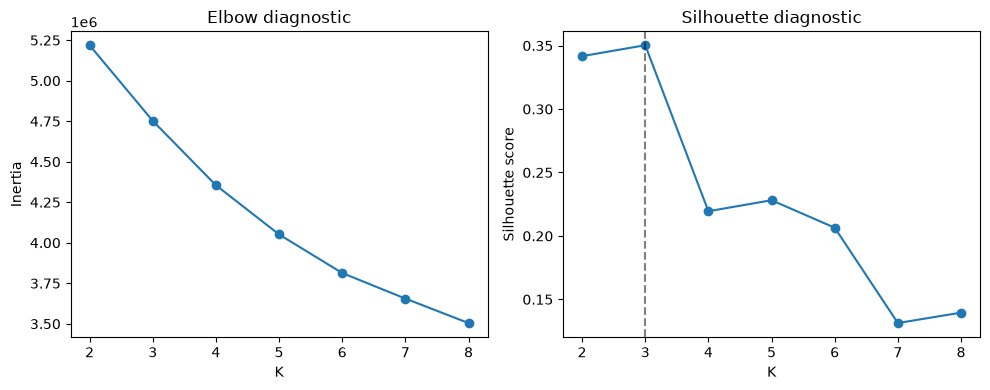

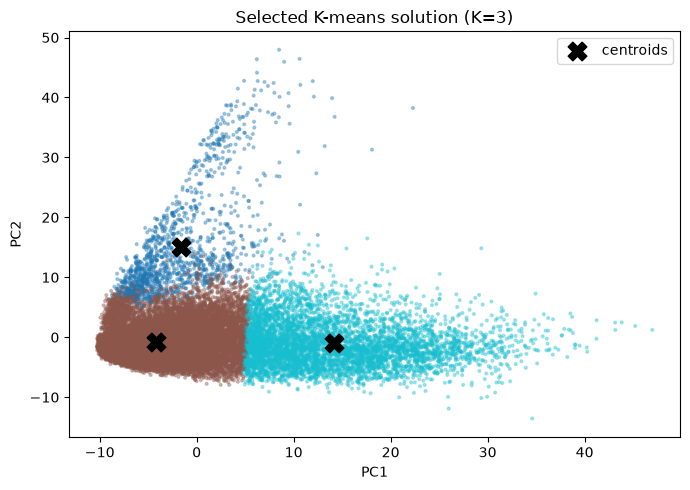

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(cluster_diagnostics["K"], cluster_diagnostics["inertia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow diagnostic")
axes[1].plot(cluster_diagnostics["K"], cluster_diagnostics["silhouette"], marker="o")
axes[1].axvline(selected_k, color="black", linestyle="--", alpha=0.5)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette diagnostic")
plt.tight_layout()
plt.show()

# Refit K-means using the selected value before external comparison.
kmeans = KMeans(n_clusters=selected_k, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_embedding_pca)

# Inspect the clustering produced by the selected K.
plt.figure(figsize=(7, 5))
plt.scatter(
    X_embedding_pca[:, 0],
    X_embedding_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=4,
    alpha=0.35,
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=180,
    c="black",
    label="centroids",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Selected K-means solution (K={selected_k})")
plt.legend()
plt.tight_layout()
plt.show()


### Hierarchial clustering

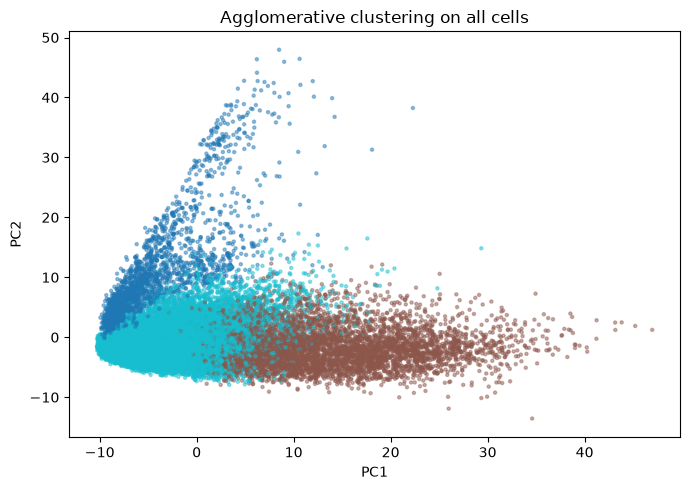

In [ ]:
hierarchical_model = AgglomerativeClustering(n_clusters=3, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_embedding_pca)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_embedding_pca[:, 0],
    X_embedding_pca[:, 1],
    c=hierarchical_labels,
    cmap="tab10",
    s=5,
    alpha=0.45,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative clustering on all cells")
plt.tight_layout()
plt.show()

In [ ]:
contingency_table = pd.crosstab(hierarchical_labels, all_sources_cleaned["label"])
print(contingency_table)

label     C     I    S
row_0                 
0      1118   585  276
1      2077  2984    0
2      8396  8408    0


Again, not great for labels.

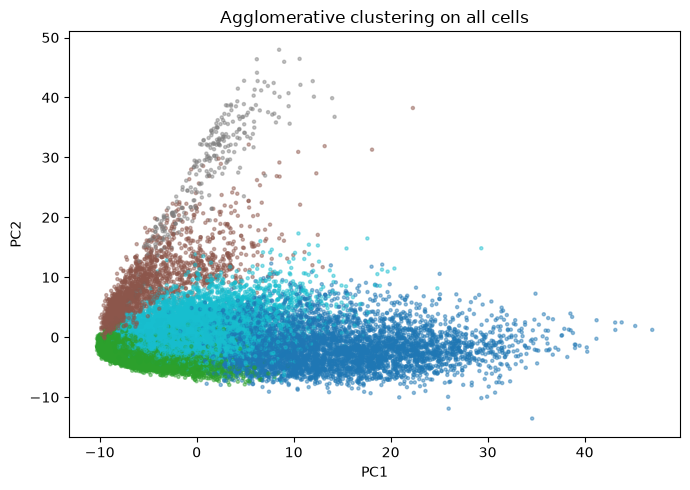

In [ ]:
hierarchical_model = AgglomerativeClustering(n_clusters=5, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_embedding_pca)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_embedding_pca[:, 0],
    X_embedding_pca[:, 1],
    c=hierarchical_labels,
    cmap="tab10",
    s=5,
    alpha=0.45,
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative clustering on all cells")
plt.tight_layout()
plt.show()

In [ ]:
contingency_table = pd.crosstab(hierarchical_labels, all_sources_cleaned["source"])
print(contingency_table)

source  alamar  chroma  jimt  mtt  study18
row_0                                     
0            0       0  5061    0        0
1           11       0  8754    4        0
2          539       0     0  425      753
3            2      13     0    0      247
4            1       0  8033    0        1


Again, the clusterring picked up technical signal much better than the biological, related to labes.

### Possible label meaning

On the practical we discussed that Value is the measure of vitality of the cell and that the homework dataset is an extension of the practical one. Therefore labels should also relate to vitality. From values associated with labels (one of the first plots in this notebook) we know that `C` are the cells with the highest vitality, than we have `S` (which is also the rarest label) and the smallest vitality is for `I` label. Therefore I think that `C` stands for `clonogenic`, `S` for `senescent` and `I` for `Inviable`.